<h1>IMPORTAÇÕES</h1>


In [27]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

<h1>TRATAMENTO DE DADOS</h1>


In [28]:
#Leitura do Dataset
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

#Remocao dos dados desnecessarios
df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

#Ajuste do indice
df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index.freq = "MS"

df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

#Ajuste da nomeclatura das colunas para o prophet
df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

#A coluna "ds" é o indice, enquanto a coluna "y" é a que será utilizada para a previsão
df.columns = ["ds", "y", "y2", "y3", "y4", "y5"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      45 non-null     datetime64[ns]
 1   y       45 non-null     int64         
 2   y2      45 non-null     int64         
 3   y3      45 non-null     int64         
 4   y4      45 non-null     int64         
 5   y5      45 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 2.2 KB


<h1>PREVISÕES</h1>


<h3>Previsões com train/test</h3>

In [29]:
train = df.iloc[:40]
test = df.iloc[39:]

# Modelo Prophet
m = Prophet(growth='flat', seasonality_mode='additive')

# Modelo treinado no dataset de treino
m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

09:22:55 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing


<Axes: xlabel='ds'>

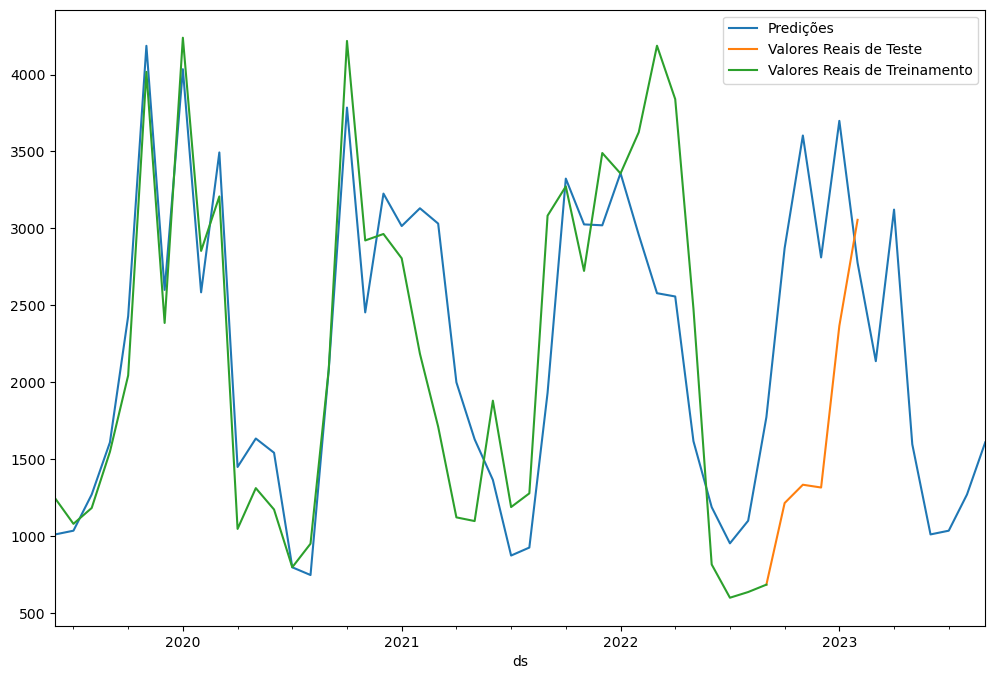

In [30]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

In [31]:
# Método do prophet para obter a performance do modelo
# initial = Período inicial de treino antes do primeiro corte
# period = Tempo entre cada corte
# horizon = Quantos dados após cada corte serão avaliados
df_cv = cross_validation(m,initial="730 days",period="90 days",horizon="180 days",parallel="processes")

09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,25 days,6.434363e+04,253.660466,241.899071,0.159007,0.159007,0.179023,0.50
1,27 days,6.011091e+06,2451.752610,1784.985931,0.466793,0.466793,0.838152,0.50
2,54 days,3.041659e+06,1744.035228,1026.868271,0.338459,0.556330,0.536473,0.25
3,56 days,1.647866e+05,405.939171,388.021876,0.198178,0.198178,0.202580,0.00
4,57 days,9.467256e+05,972.998239,893.198135,0.351207,0.351207,0.433059,0.00
5,58 days,1.566886e+06,1251.753008,1251.447465,0.426891,0.426891,0.550954,0.00
6,85 days,1.466477e+06,1210.981686,1210.913203,0.363096,0.363096,0.444230,0.00
7,86 days,5.876259e+06,2424.099562,2052.263225,0.508327,0.508327,0.786853,0.00
8,88 days,3.157399e+06,1776.907111,1357.243026,0.659441,0.804418,0.681823,0.00
9,115 days,2.351195e+05,484.891269,420.133900,0.432476,0.432476,0.314875,0.50


A funcao `performance_metrics` nos informa quais são as métricas de performance para cada tempo que queremos prever, por exemplo, se queremos prever 30 dias no futuro, nos referimos a linha que diz 30 dias, e estas serão as métricas para estes casos

<h3>Previsões sem train/test</h3>

In [33]:
df.columns = ["ds", "y1", "y", "y3", "y4", "y5"]

In [34]:
m = Prophet(growth='flat',yearly_seasonality=11)

m.fit(df)

09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,6423.2026,6036.318483,7723.334756,6423.2026,6423.2026,466.913740,466.913740,466.913740,466.913740,466.913740,466.913740,0.0,0.0,0.0,6890.116340
1,2019-07-01,6423.2026,5353.427387,7178.767300,6423.2026,6423.2026,-155.443356,-155.443356,-155.443356,-155.443356,-155.443356,-155.443356,0.0,0.0,0.0,6267.759244
2,2019-08-01,6423.2026,5002.310582,6763.292520,6423.2026,6423.2026,-529.143767,-529.143767,-529.143767,-529.143767,-529.143767,-529.143767,0.0,0.0,0.0,5894.058833
3,2019-09-01,6423.2026,5804.950056,7600.263704,6423.2026,6423.2026,268.016067,268.016067,268.016067,268.016067,268.016067,268.016067,0.0,0.0,0.0,6691.218667
4,2019-10-01,6423.2026,5962.152005,7718.835113,6423.2026,6423.2026,449.014712,449.014712,449.014712,449.014712,449.014712,449.014712,0.0,0.0,0.0,6872.217312


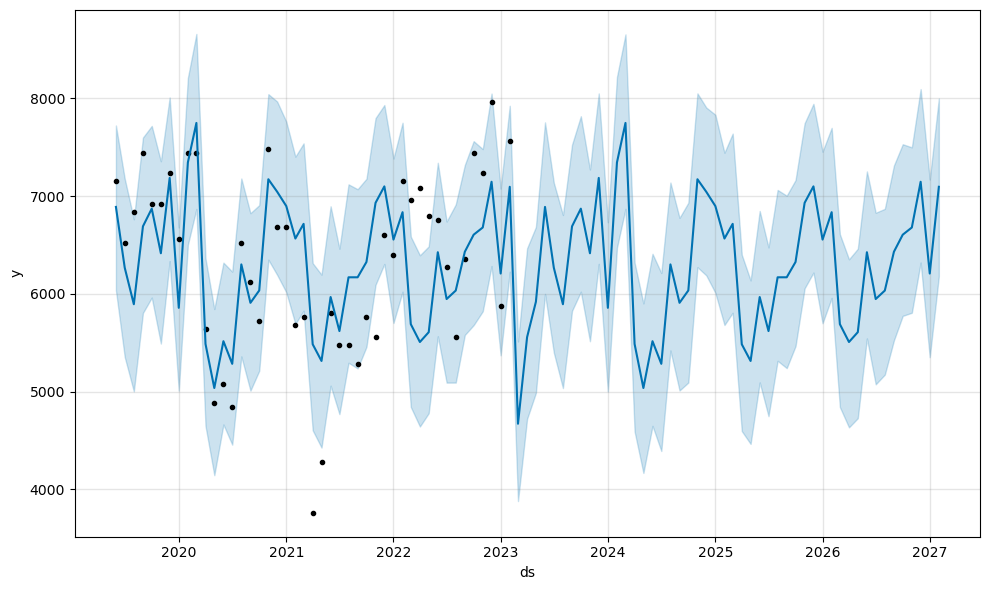

In [36]:
m.plot(forecast);

<Axes: title={'center': 'Predições Empresa 1 - Prophet'}, xlabel='Data', ylabel='Consumo(KWh)'>

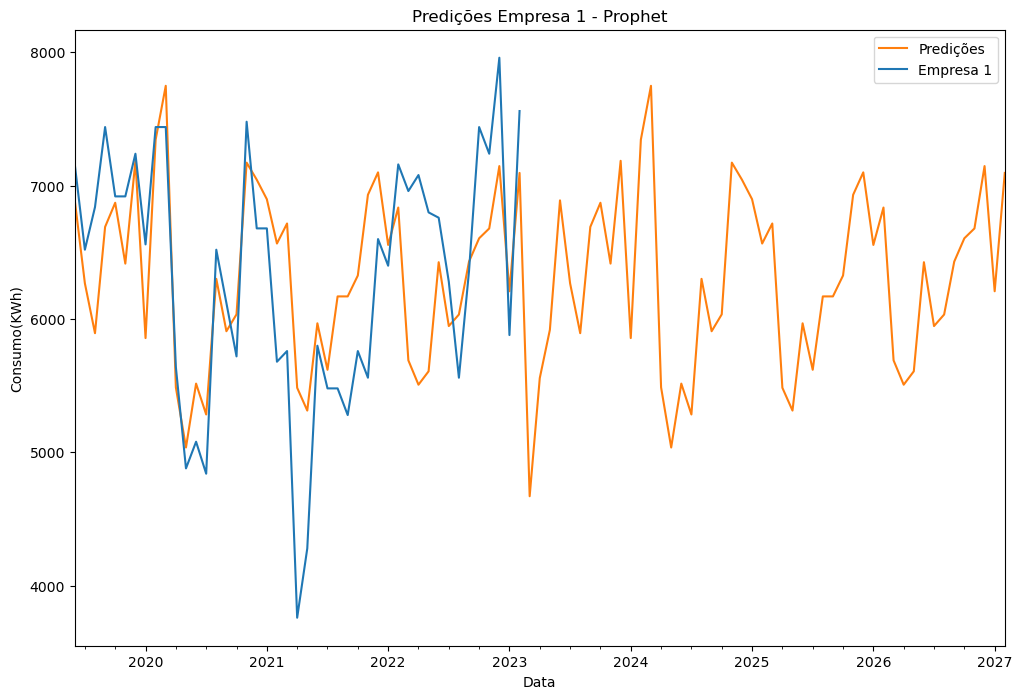

In [37]:
xlabel="Data"
ylabel="Consumo(KWh)"
title="Predições Empresa 1 - Prophet"

ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8), color="#ff7f0e")
df.plot(x='ds',y='y',label='Empresa 1',legend=True,ax=ax,color="#1f77b4",title=title,xlabel=xlabel,ylabel=ylabel)
#plt.savefig("Prophet - Empresa1pred.png")

In [38]:
df_cv = cross_validation(m,initial="1095 days",period="30 days",horizon="60 days",parallel="processes")

09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] start processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing
09:22:56 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,25 days,184694.802446,429.761332,429.761332,0.068433,0.068433,0.070858,1.0
1,26 days,471548.487775,686.693882,686.693882,0.123506,0.123506,0.116323,1.0
2,27 days,702336.822331,838.055381,646.466619,0.088182,0.088182,0.094931,0.5
3,28 days,981165.705724,990.538089,973.776220,0.127283,0.127283,0.136128,0.5
4,29 days,221347.836767,470.476181,470.476181,0.080013,0.080013,0.076935,1.0
5,56 days,466615.134071,683.092332,683.092332,0.122858,0.122858,0.115748,1.0
6,57 days,702581.006466,838.201054,645.487949,0.088023,0.088023,0.094781,0.5
7,58 days,975123.002592,987.483166,970.484619,0.126843,0.126843,0.135629,0.5
8,59 days,226619.861732,476.046071,476.046071,0.080960,0.080960,0.077810,1.0
9,60 days,437729.309713,661.611147,661.611147,0.087515,0.087515,0.091519,1.0
